# Churn: preparação e comparação de modelos

Este notebook prepara os dados e compara regressão logística e floresta aleatória na mesma divisão de treino e teste. Execute uma célula por vez e observe os resultados antes de continuar.

Usamos o arquivo original `customer_churn_ml.csv`, sem sobrescrevê-lo. Selecione o ambiente `.venv` desta pasta como kernel do notebook. Se o editor solicitar `ipykernel`, instale-o nesse ambiente.

**Ordem:** carregar → separar entradas e alvo → dividir treino/teste → preparar → treinar → prever → avaliar.

A divisão vem antes dos preenchimentos: medianas e categorias devem ser aprendidas apenas com o treino. O teste representa clientes reservados para uma avaliação futura.

## 1. Importar as ferramentas e carregar o CSV

`pandas` organiza os dados em tabelas. `numpy` ajuda a verificar os números. As ferramentas do `scikit-learn` dividem e transformam os dados. O `matplotlib` ficará para a etapa de gráficos.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# Aceita executar o notebook na pasta do projeto ou na pasta principal.
caminho_csv = Path("../data/customer_churn_ml.csv")
if not caminho_csv.exists():
    caminho_csv = Path("3 - Projeto Machine Learning") / caminho_csv

dados = pd.read_csv(caminho_csv)

print(f"Base original: {dados.shape[0]} clientes e {dados.shape[1]} colunas.")
display(dados.head())
display(dados.isna().sum().rename("Valores ausentes").to_frame())

Base original: 1500 clientes e 18 colunas.


,Cliente_ID,Genero,Idade,Parceiro,Dependentes,Tempo_Cliente_Meses,Tipo_Contrato,Servico_Internet,Suporte_Tecnico,Streaming,Cobranca_Sem_Papel,Metodo_Pagamento,Chamadas_Suporte_6M,Atrasos_Pagamento_12M,Valor_Mensal,Valor_Total,Satisfacao,Churn
0,CLI00001,Masculino,19.0,Não,Sim,15,Mensal,DSL,Sim,Sim,Sim,Boleto,0,4,92.89,1366.08,3.0,Sim
1,CLI00002,Masculino,63.0,Sim,Não,43,Bienal,Sem Internet,Não Aplicável,Não Aplicável,Não,Débito Automático,1,1,19.36,832.74,4.0,Não
2,CLI00003,Feminino,43.0,Não,Não,15,Mensal,DSL,Sim,Não,Sim,Boleto,1,3,95.91,1463.83,2.0,Não
3,CLI00004,Masculino,50.0,Não,Não,21,Anual,DSL,Não,Não,Sim,Boleto,2,2,37.29,801.59,5.0,Não
4,CLI00005,Feminino,46.0,Não,Não,19,Mensal,Fibra,Sim,Não,Sim,Boleto,0,3,84.17,1543.36,3.0,Não


,Valores ausentes
Cliente_ID,0
Genero,18
Idade,26
Parceiro,0
Dependentes,0
Tempo_Cliente_Meses,0
Tipo_Contrato,0
Servico_Internet,0
Suporte_Tecnico,30
Streaming,0


## 2. Separar X e y

**X** contém as características dos clientes. **y** contém a resposta: `1` para churn e `0` para permanência.

Retiramos `Churn` de X porque ela é a resposta que queremos prever. Retiramos `Cliente_ID` porque ele apenas identifica cada cliente. Nenhuma linha será excluída nesta preparação.

In [2]:
# Confere o alvo antes de converter: não devemos inventar respostas ausentes.
if dados["Churn"].isna().any() or not dados["Churn"].isin(["Sim", "Não"]).all():
    raise ValueError("Revise Churn: o alvo deve conter apenas Sim ou Não, sem nulos.")

X = dados.drop(columns=["Cliente_ID", "Churn"]).copy()
y = dados["Churn"].map({"Não": 0, "Sim": 1}).astype("int64")

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)
display(y.value_counts().sort_index().rename("Clientes").to_frame())

Formato de X: (1500, 16)
Formato de y: (1500,)


,Clientes
Churn,
0,961
1,539


## 3. Separar variáveis numéricas e categóricas

A seleção abaixo usa o significado das colunas, além do tipo armazenado. `Satisfacao` é ordinal: suas notas de 1 a 5 têm ordem. Vamos preservá-las como números e preencher as notas ausentes com a mais frequente. Isso evita criar uma nota intermediária inexistente.

As outras categorias, como tipo de contrato, serão transformadas em indicadores de 0 e 1.

In [3]:
# Medidas e contagens: preencheremos os valores ausentes com a mediana.
colunas_numericas = [
    "Idade",
    "Tempo_Cliente_Meses",
    "Chamadas_Suporte_6M",
    "Atrasos_Pagamento_12M",
    "Valor_Mensal",
    "Valor_Total",
]

# Nota ordenada: terá um tratamento próprio.
colunas_ordinais = ["Satisfacao"]

# Grupos e respostas em texto: não têm uma escala numérica definida.
colunas_categoricas = [
    "Genero",
    "Parceiro",
    "Dependentes",
    "Tipo_Contrato",
    "Servico_Internet",
    "Suporte_Tecnico",
    "Streaming",
    "Cobranca_Sem_Papel",
    "Metodo_Pagamento",
]

# Garante que nenhuma entrada ficou sem tratamento ou foi listada duas vezes.
colunas_definidas = colunas_numericas + colunas_ordinais + colunas_categoricas
assert len(colunas_definidas) == len(set(colunas_definidas))
assert set(colunas_definidas) == set(X.columns)

print("Numéricas:", colunas_numericas)
print("Ordinal:", colunas_ordinais)
print("Categóricas em texto:", colunas_categoricas)

Numéricas: ['Idade', 'Tempo_Cliente_Meses', 'Chamadas_Suporte_6M', 'Atrasos_Pagamento_12M', 'Valor_Mensal', 'Valor_Total']
Ordinal: ['Satisfacao']
Categóricas em texto: ['Genero', 'Parceiro', 'Dependentes', 'Tipo_Contrato', 'Servico_Internet', 'Suporte_Tecnico', 'Streaming', 'Cobranca_Sem_Papel', 'Metodo_Pagamento']


## 4. Dividir treino e teste

Reservamos **80% para treino** e **20% para teste**. `stratify=y` mantém aproximadamente a proporção de churn nos dois grupos. `random_state=42` permite repetir a mesma divisão ao executar novamente com os mesmos dados.

O teste não será usado para escolher como preencher os dados. Como a base não tem datas, esta é uma divisão aleatória para o exercício; uma aplicação real ainda exige confirmar quando cada informação foi registrada.

In [4]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print(f"Treino: {len(X_treino)} clientes.")
print(f"Teste: {len(X_teste)} clientes.")

# Compara as proporções, sem treinar nenhum modelo.
proporcoes = pd.DataFrame({
    "Base (%)": y.value_counts(normalize=True).sort_index() * 100,
    "Treino (%)": y_treino.value_counts(normalize=True).sort_index() * 100,
    "Teste (%)": y_teste.value_counts(normalize=True).sort_index() * 100,
})
display(proporcoes.rename(index={0: "Não", 1: "Sim"}).round(2))

Treino: 1200 clientes.
Teste: 300 clientes.


,Base (%),Treino (%),Teste (%)
Churn,,,
Não,64.07,64.08,64.0
Sim,35.93,35.92,36.0


## 5. Definir os tratamentos e a codificação

- **Numéricas:** preencher com a mediana, o valor central dos dados ordenados. Ela sofre menos influência de valores extremos que a média. É uma escolha inicial simples e não recupera o valor verdadeiro que está faltando.
- **Satisfação:** preencher com a moda, a nota mais frequente no treino. Preservar a escala numérica é uma escolha inicial que poderemos revisar depois.
- **Textos:** preencher com `Não Informado`. Assim, não adivinhamos gênero ou contratação de suporte. `Não Aplicável` continua sendo uma categoria diferente.
- **Codificação one-hot:** criar uma coluna para cada categoria. Por exemplo, `Tipo_Contrato_Mensal` vale 1 quando o contrato é mensal e 0 nos demais casos. Isso evita inventar uma ordem entre categorias.

`Pipeline` encadeia o preenchimento e a codificação. `ColumnTransformer` aplica cada tratamento às colunas correspondentes. Nesta etapa de preparação, ambos contêm somente transformações, sem classificador.

`handle_unknown="ignore"` permite transformar uma categoria nova no teste: seus indicadores naquela variável ficam em zero. `sparse_output=False` facilita visualizar a tabela resultante nesta base pequena.

In [5]:
# Até aqui só definimos as regras; nenhuma estatística foi calculada.
tratamento_numerico = SimpleImputer(strategy="median")

tratamento_ordinal = SimpleImputer(strategy="most_frequent")

tratamento_categorico = Pipeline(steps=[
    ("preencher", SimpleImputer(
        strategy="constant",
        fill_value="Não Informado",
    )),
    ("codificar", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False,
    )),
])

preprocessador = ColumnTransformer(
    transformers=[
        ("numericas", tratamento_numerico, colunas_numericas),
        ("ordinal", tratamento_ordinal, colunas_ordinais),
        ("categoricas", tratamento_categorico, colunas_categoricas),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

## 6. Aprender as transformações no treino e aplicá-las ao teste

`fit_transform` calcula as medianas, a moda e as categorias usando **somente X_treino**, e transforma esse conjunto. `transform` aplica ao teste exatamente as regras já aprendidas.

Aqui, `fit` significa ajustar o **preprocessamento**. Não estamos treinando um modelo para prever churn, e y não é passado ao preprocessador.

Reconstruímos DataFrames com os nomes das colunas e os índices originais para facilitar a leitura e manter cada cliente alinhado com sua resposta.

In [6]:
# Aprende os preenchimentos e as categorias somente no treino.
matriz_treino = preprocessador.fit_transform(X_treino)

# Reutiliza as mesmas regras no teste, sem chamar fit novamente.
matriz_teste = preprocessador.transform(X_teste)

nomes_colunas = preprocessador.get_feature_names_out()

X_treino_preparado = pd.DataFrame(
    matriz_treino,
    columns=nomes_colunas,
    index=X_treino.index,
)
X_teste_preparado = pd.DataFrame(
    matriz_teste,
    columns=nomes_colunas,
    index=X_teste.index,
)

# Mostra os preenchimentos efetivamente aprendidos no treino.
display(pd.Series(
    preprocessador.named_transformers_["numericas"].statistics_,
    index=colunas_numericas,
    name="Mediana no treino",
).to_frame())

print(
    "Nota usada para satisfação ausente:",
    preprocessador.named_transformers_["ordinal"].statistics_[0],
)
display(X_treino_preparado.head())

Nota usada para satisfação ausente: 4.0


,Mediana no treino
Idade,46.00
Tempo_Cliente_Meses,30.00
Chamadas_Suporte_6M,1.00
Atrasos_Pagamento_12M,1.00
Valor_Mensal,85.52
Valor_Total,2131.19


,Idade,Tempo_Cliente_Meses,Chamadas_Suporte_6M,Atrasos_Pagamento_12M,Valor_Mensal,Valor_Total,Satisfacao,Genero_Feminino,Genero_Masculino,Genero_Não Informado,Parceiro_Não,Parceiro_Sim,Dependentes_Não,Dependentes_Sim,Tipo_Contrato_Anual,Tipo_Contrato_Bienal,Tipo_Contrato_Mensal,Servico_Internet_DSL,Servico_Internet_Fibra,Servico_Internet_Sem Internet,Suporte_Tecnico_Não,Suporte_Tecnico_Não Aplicável,Suporte_Tecnico_Não Informado,Suporte_Tecnico_Sim,Streaming_Não,Streaming_Não Aplicável,Streaming_Sim,Cobranca_Sem_Papel_Não,Cobranca_Sem_Papel_Sim,Metodo_Pagamento_Boleto,Metodo_Pagamento_Cartão de Crédito,Metodo_Pagamento_Débito Automático,Metodo_Pagamento_PIX
938,72.0,13.0,0.0,1.0,82.02,1043.74,3.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
959,71.0,17.0,1.0,0.0,126.77,2156.88,3.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
722,52.0,10.0,0.0,2.0,63.15,642.81,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
1391,35.0,42.0,2.0,0.0,106.39,4540.71,5.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1059,32.0,27.0,2.0,1.0,80.06,2199.20,4.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0


## 7. Conferir a preparação

Verificamos se restou algum valor ausente, se os números são finitos e se treino e teste têm as mesmas colunas. Também conferimos se nenhum cliente aparece nos dois grupos e se as respostas continuam alinhadas.

Os objetos para a próxima etapa serão `X_treino_preparado`, `X_teste_preparado`, `y_treino` e `y_teste`. Os dados originais continuam preservados em `dados`, `X_treino` e `X_teste`.

In [7]:
# Não deve restar nenhum valor ausente ou infinito nas entradas preparadas.
assert not X_treino_preparado.isna().any().any()
assert not X_teste_preparado.isna().any().any()
assert np.isfinite(X_treino_preparado.to_numpy()).all()
assert np.isfinite(X_teste_preparado.to_numpy()).all()

# As duas tabelas precisam ter colunas iguais, na mesma ordem.
assert X_treino_preparado.columns.equals(X_teste_preparado.columns)

# Os clientes de treino e teste devem ser distintos.
assert X_treino.index.intersection(X_teste.index).empty
assert len(X_treino) + len(X_teste) == len(dados)

# Cada linha continua associada à resposta do mesmo cliente.
assert X_treino_preparado.index.equals(y_treino.index)
assert X_teste_preparado.index.equals(y_teste.index)

print("Treino preparado:", X_treino_preparado.shape)
print("Teste preparado:", X_teste_preparado.shape)
print("Valores ausentes após a preparação: 0.")
print("Verificações concluídas. Nenhum modelo de classificação foi treinado.")

Treino preparado: (1200, 33)
Teste preparado: (300, 33)
Valores ausentes após a preparação: 0.
Verificações concluídas. Nenhum modelo de classificação foi treinado.


A preparação termina aqui. Nas próximas células, adicionamos padronização de escala e regressão logística. Revise os resultados da preparação antes de continuar.

Se futuramente usarmos validação cruzada, o preprocessador deverá ficar junto do modelo em uma Pipeline para reaprender as transformações em cada divisão interna de treino.

Referência: [scikit-learn — prevenção de vazamento de dados](https://scikit-learn.org/1.8/common_pitfalls.html#data-leakage).

## 8. Criar e treinar a regressão logística

Apesar do nome, a regressão logística é usada para **classificação**. Ela combina as características do cliente para estimar a probabilidade de churn. Durante o treinamento, ajusta os pesos dessas características usando as respostas conhecidas de `y_treino`.

Vamos reunir preparação, padronização e classificação em uma única `Pipeline`. Ela receberá **X_treino original**, sem o identificador e o alvo. As tabelas preparadas anteriores continuam úteis para estudar as transformações, mas a Pipeline completa refaz esses passos internamente.

`clone(preprocessador)` copia as regras de preparação sem carregar as estatísticas já calculadas. Isso mantém o modelo completo e permite reaprender as transformações dentro do treino se futuramente usarmos validação cruzada.

`StandardScaler` centraliza e ajusta a escala de cada coluna transformada usando a média e o desvio padrão do treino. Isso ajuda o ajuste numérico e a regularização da regressão logística. Nesta versão, os indicadores de categorias também são padronizados.

Usamos `solver="lbfgs"`, `C=1.0` e nenhuma ponderação de classes. `C` controla a intensidade da regularização, que limita pesos excessivos. `max_iter=1000` é o limite de iterações para o algoritmo encontrar uma solução; não significa treinar mil modelos. Essas configurações foram definidas antes de observar o resultado no teste.

In [8]:
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.preprocessing import StandardScaler

# A Pipeline recebe as características antes do preenchimento e da codificação.
modelo_base = Pipeline(steps=[
    ("preparar", clone(preprocessador)),
    ("padronizar", StandardScaler()),
    ("classificar", LogisticRegression(
        solver="lbfgs",
        C=1.0,
        max_iter=1000,
        class_weight=None,
    )),
])

# Aprende as transformações e os pesos do modelo usando somente o treino.
modelo_base.fit(X_treino, y_treino)

print(f"Modelo treinado com {len(X_treino)} clientes.")
print("Iterações realizadas:", modelo_base.named_steps["classificar"].n_iter_[0])

Modelo treinado com 1200 clientes.
Iterações realizadas: 25


## 9. Fazer previsões no conjunto de teste

O modelo recebe os 300 clientes reservados para teste e aplica as transformações aprendidas no treino. `predict` retorna a classe prevista: **0 = permaneceu** e **1 = saiu**.

`predict_proba` retorna probabilidades estimadas. Selecionamos a coluna correspondente à classe 1. Para este problema binário, `predict` usa o limiar padrão de 50%: probabilidades acima de 50% indicam churn. No empate exato, o scikit-learn escolhe a classe 0.

O alvo verdadeiro `y_teste` será usado somente para avaliar as previsões. A probabilidade estimada não é uma garantia de saída.

In [9]:
# Previsões dos clientes que não participaram do treinamento.
y_previsto = modelo_base.predict(X_teste)

# Localiza explicitamente a coluna da classe positiva (churn = 1).
indice_churn = list(modelo_base.classes_).index(1)
probabilidade_churn = modelo_base.predict_proba(X_teste)[:, indice_churn]

# O identificador aparece apenas para consulta; ele não entrou no modelo.
previsoes_teste = pd.DataFrame({
    "Cliente_ID": dados.loc[X_teste.index, "Cliente_ID"],
    "Churn_real": y_teste,
    "Churn_previsto": y_previsto,
    "Probabilidade_churn": probabilidade_churn,
}, index=X_teste.index)

display(previsoes_teste.head(10).round(3))

,Cliente_ID,Churn_real,Churn_previsto,Probabilidade_churn
1399,CLI01400,0,0,0.041
89,CLI00090,0,0,0.094
1386,CLI01387,1,1,0.785
361,CLI00362,1,0,0.332
928,CLI00929,1,0,0.440
1260,CLI01261,1,1,0.782
710,CLI00711,1,0,0.183
1017,CLI01018,0,1,0.811
606,CLI00607,0,0,0.046
0,CLI00001,1,1,0.608


## 10. Calcular accuracy, precision, recall e F1-score

Todas as métricas abaixo usam o **conjunto de teste**. Para precision, recall e F1, consideramos **churn = 1** como a classe positiva.

| Métrica | Pergunta que responde | Cálculo |
|---|---|---|
| Accuracy (acurácia) | De todos os clientes, quantos foram classificados corretamente? | Acertos / total |
| Precision (precisão) | Dos clientes sinalizados como churn, quantos realmente saíram? | VP / (VP + FP) |
| Recall (sensibilidade) | Dos clientes que realmente saíram, quantos o modelo identificou? | VP / (VP + FN) |
| F1-score | Como está o equilíbrio entre precision e recall? | 2 × precision × recall / (precision + recall) |

**VP:** churn identificado corretamente. **FP:** alarme falso de churn. **FN:** churn que passou despercebido. O F1 é uma média harmônica, que penaliza quando precision ou recall é muito baixa. Ele não considera diretamente os verdadeiros negativos nem os custos financeiros de cada erro.

Os valores vão de 0 a 1; exibimos como porcentagem. `zero_division=0` define resultado zero se uma divisão ficar indefinida, por exemplo, se o modelo não sinalizar nenhum cliente como churn.

Também calculamos a accuracy de uma regra simples: responder sempre a classe mais frequente no treino. Isso ajuda a interpretar a accuracy do modelo.

In [10]:
# pos_label=1 deixa explícito que estamos avaliando a identificação de churn.
metricas = pd.Series({
    "Accuracy": accuracy_score(y_teste, y_previsto),
    "Precision": precision_score(y_teste, y_previsto, pos_label=1, zero_division=0),
    "Recall": recall_score(y_teste, y_previsto, pos_label=1, zero_division=0),
    "F1-score": f1_score(y_teste, y_previsto, pos_label=1, zero_division=0),
}, name="Resultado")

display((metricas * 100).round(2).rename("Resultado (%)").to_frame())

# Define a classe da referência usando apenas o treino, sem ajustar outro modelo.
classe_majoritaria = y_treino.mode().iloc[0]
previsao_referencia = np.full(len(y_teste), classe_majoritaria)
accuracy_referencia = accuracy_score(y_teste, previsao_referencia)

print(f"Accuracy da regra de classe majoritária: {accuracy_referencia:.2%}")
print(f"Clientes sinalizados como churn: {int((y_previsto == 1).sum())}")

Accuracy da regra de classe majoritária: 64.00%
Clientes sinalizados como churn: 73


,Resultado (%)
Accuracy,74.33
Precision,71.23
Recall,48.15
F1-score,57.46


## 11. Construir e interpretar a matriz de confusão

A matriz mostra **quantidades de clientes**, em vez de porcentagens. As **linhas são os valores reais** e as **colunas são as previsões**.

| | Previu: Não | Previu: Sim |
|---|---|---|
| Real: Não | Verdadeiro negativo (VN): permaneceu e foi classificado corretamente | Falso positivo (FP): permaneceu, mas recebeu um alerta de churn |
| Real: Sim | Falso negativo (FN): saiu, mas o modelo não identificou | Verdadeiro positivo (VP): saiu e o modelo identificou |

Um falso negativo pode representar uma oportunidade perdida de retenção. Um falso positivo pode levar a contato ou incentivo desnecessário.

VN: 171 clientes permaneceram e foram classificados corretamente.
FP: 21 clientes permaneceram, mas receberam um alerta de churn.
FN: 56 clientes saíram e não foram identificados.
VP: 52 clientes saíram e foram identificados.


,Previu: Não (0),Previu: Sim (1)
Real: Não (0),171,21
Real: Sim (1),56,52


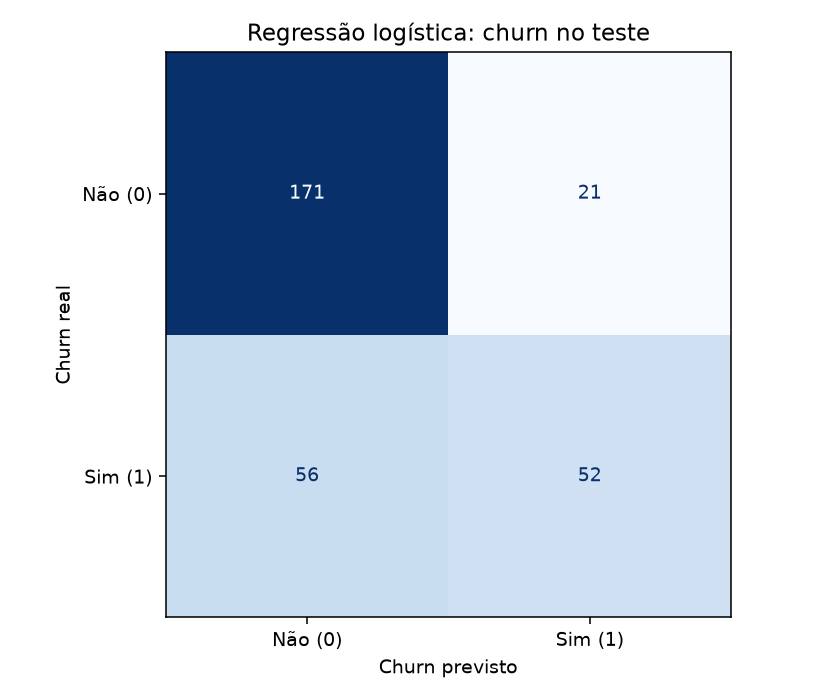

In [11]:
# labels=[0, 1] fixa a ordem das linhas e colunas.
matriz_confusao = confusion_matrix(y_teste, y_previsto, labels=[0, 1])
vn, fp, fn, vp = matriz_confusao.ravel()

display(pd.DataFrame(
    matriz_confusao,
    index=["Real: Não (0)", "Real: Sim (1)"],
    columns=["Previu: Não (0)", "Previu: Sim (1)"],
))

# Desenha a matriz com matplotlib, usando contagens inteiras.
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusao,
    display_labels=["Não (0)", "Sim (1)"],
).plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_title("Regressão logística: churn no teste")
ax.set_xlabel("Churn previsto")
ax.set_ylabel("Churn real")
fig.tight_layout()
plt.show()

print(f"VN: {vn} clientes permaneceram e foram classificados corretamente.")
print(f"FP: {fp} clientes permaneceram, mas receberam um alerta de churn.")
print(f"FN: {fn} clientes saíram e não foram identificados.")
print(f"VP: {vp} clientes saíram e foram identificados.")

# Confere se a matriz cobre todos os clientes e reproduz a accuracy.
assert matriz_confusao.sum() == len(y_teste)
assert np.isclose((vn + vp) / matriz_confusao.sum(), metricas["Accuracy"])

## 12. Quais métricas priorizar em churn?

**Recall costuma ser a prioridade quando perder um cliente custa mais do que fazer um contato extra.** Um recall maior significa deixar passar menos clientes que realmente saem.

**Precision ganha importância quando as ações de retenção são caras ou a equipe tem capacidade limitada.** Ela mostra quanto dos alertas corresponde a churn observado, evitando tratar todo alerta como se estivesse correto.

**F1 ajuda a acompanhar precision e recall juntas**, mas não substitui a escolha baseada nos custos e na capacidade de atendimento. **Accuracy é complementar:** pode parecer razoável mesmo quando o modelo não identifica os clientes que saem.

Para este projeto, vamos observar principalmente recall e precision, acompanhando o F1. Sem informações sobre custos e orçamento, ainda não podemos definir uma métrica ou um limiar ideal.

O modelo prevê saída, mas não mede se uma campanha conseguiria evitar essa saída. As métricas representam apenas esta divisão de treino e teste. Melhorias futuras devem ser escolhidas por validação dentro do treino, sem ajustar parâmetros repetidamente para melhorar o resultado deste teste.

Nas próximas células, comparamos este modelo base com uma floresta aleatória, mantendo a mesma divisão de treino e teste.

Referências: [LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html), [precision](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html), [recall](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html), [F1](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html) e [matriz de confusão](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html).

## 13. Treinar RandomForestClassifier com a mesma divisão

Uma floresta aleatória combina várias árvores de decisão. Cada árvore aprende regras a partir de uma amostra dos clientes de treino e considera subconjuntos de características. O conjunto pode representar relações não lineares e interações entre variáveis.

Vamos reutilizar **exatamente `X_treino`, `X_teste`, `y_treino` e `y_teste`**. Não faremos outra divisão. A regressão logística mantém suas configurações anteriores.

A floresta receberá os mesmos preenchimentos e a mesma codificação, aprendidos somente no treino. Não adicionamos `StandardScaler` à floresta porque as árvores usam cortes nos valores das colunas, sem exigir que tenham escalas semelhantes.

Usamos uma configuração inicial com `n_estimators=100` (100 árvores), `random_state=42` para repetibilidade e `class_weight=None`, assim como na regressão logística. Os demais parâmetros ficam nos padrões da biblioteca. Não buscamos parâmetros melhores no teste. Ambos os modelos usam `predict`, com a decisão binária padrão em torno de 50% de probabilidade.

Referência: [scikit-learn — RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html).

In [12]:
from sklearn.ensemble import RandomForestClassifier

# Reutiliza as regras de preparação, sem compartilhar estatísticas entre modelos.
modelo_floresta = Pipeline(steps=[
    ("preparar", clone(preprocessador)),
    ("classificar", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight=None,
        n_jobs=-1,
    )),
])

# Usa os mesmos 1.200 clientes de treino da regressão logística.
modelo_floresta.fit(X_treino, y_treino)

# Avalia nos mesmos 300 clientes de teste.
y_previsto_floresta = modelo_floresta.predict(X_teste)

# Garante que ambos receberam a mesma representação antes da padronização.
np.testing.assert_allclose(
    modelo_floresta.named_steps["preparar"].transform(X_teste),
    modelo_base.named_steps["preparar"].transform(X_teste),
)

print(f"Random Forest treinado com {len(X_treino)} clientes.")
print(f"Previsões geradas para os mesmos {len(X_teste)} clientes de teste.")

Random Forest treinado com 1200 clientes.
Previsões geradas para os mesmos 300 clientes de teste.


## 14. Comparar as métricas e os tipos de erro

Calculamos as quatro métricas com a mesma função e com **churn = 1** como classe positiva. Os valores exibidos na primeira tabela estão em porcentagem.

Para entender as consequências, a segunda tabela mostra os clientes que saíram e foram identificados, os que passaram despercebidos e os alarmes falsos. Maior recall significa menos saídas não identificadas. Maior precision significa que uma proporção maior dos alertas está correta.

In [13]:
# A mesma função evita usar definições diferentes para comparar os modelos.
def calcular_metricas(y_real, y_predito):
    return {
        "Accuracy": accuracy_score(y_real, y_predito),
        "Precision": precision_score(y_real, y_predito, pos_label=1, zero_division=0),
        "Recall": recall_score(y_real, y_predito, pos_label=1, zero_division=0),
        "F1-score": f1_score(y_real, y_predito, pos_label=1, zero_division=0),
    }

# Mantém as previsões da regressão logística da etapa anterior.
previsoes_por_modelo = {
    "LogisticRegression": y_previsto,
    "RandomForestClassifier": y_previsto_floresta,
}

comparacao_modelos = pd.DataFrame.from_dict({
    nome: calcular_metricas(y_teste, previsao)
    for nome, previsao in previsoes_por_modelo.items()
}, orient="index")
comparacao_modelos.index.name = "Modelo"

print("Métricas no teste (%); classe positiva: churn = 1.")
display((comparacao_modelos * 100).round(2))

# Explica a diferença das métricas em quantidades de clientes.
contagens = {}
for nome, previsao in previsoes_por_modelo.items():
    vn_modelo, fp_modelo, fn_modelo, vp_modelo = confusion_matrix(
        y_teste, previsao, labels=[0, 1]
    ).ravel()
    contagens[nome] = {
        "Churn identificado (VP)": vp_modelo,
        "Churn não identificado (FN)": fn_modelo,
        "Alarmes falsos (FP)": fp_modelo,
        "Permanência correta (VN)": vn_modelo,
    }

comparacao_erros = pd.DataFrame.from_dict(contagens, orient="index")
comparacao_erros.index.name = "Modelo"
display(comparacao_erros)

# As contagens de cada modelo devem cobrir exatamente o mesmo teste.
assert comparacao_erros.sum(axis=1).eq(len(y_teste)).all()
assert comparacao_modelos.ge(0).all().all()
assert comparacao_modelos.le(1).all().all()

Métricas no teste (%); classe positiva: churn = 1.


,Accuracy,Precision,Recall,F1-score
Modelo,,,,
LogisticRegression,74.33,71.23,48.15,57.46
RandomForestClassifier,74.33,73.85,44.44,55.49


,Churn identificado (VP),Churn não identificado (FN),Alarmes falsos (FP),Permanência correta (VN)
Modelo,,,,
LogisticRegression,52,56,21,171
RandomForestClassifier,48,60,17,175


## 15. Interpretar a comparação

**Nesta execução, a regressão logística parece a melhor referência inicial quando a prioridade é identificar clientes que saem.** A accuracy empatou em 74,33%, mas a regressão logística teve recall de 48,15% e F1 de 57,46%, contra 44,44% e 55,49% da floresta.

Dos 108 clientes que saíram, a regressão logística identificou 52 e deixou passar 56. A floresta identificou 48 e deixou passar 60. Portanto, a logística identificou quatro casos adicionais, ao custo de quatro alarmes falsos adicionais: 21 contra 17.

A floresta teve maior precision: 73,85%, contra 71,23% da logística. Ela sinalizou menos clientes e uma proporção maior dos seus alertas estava correta. Se as ações de retenção forem caras, essa vantagem merece consideração. Sem conhecer os custos de cada erro, não podemos afirmar qual opção traz maior retorno financeiro.

Ambos identificaram menos da metade dos casos de churn. A preferência pela logística é inicial e depende do objetivo de recuperar mais casos; não significa que seu desempenho já seja suficiente para uso real.

Esta comparação descreve o desempenho destes dois modelos, com estas configurações, neste mesmo teste. Ela não demonstra que um algoritmo será sempre melhor. Como agora usamos o teste para comparar alternativas, a preferência é exploratória; uma escolha mais robusta exigirá validação cruzada dentro do treino e uma avaliação final em dados ainda não usados na escolha.

Esta etapa termina na comparação. Alterações de parâmetros, pesos de classes ou limiares ficam para uma próxima etapa.